<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/main/project_jenny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [6]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jennifershearer","key":"5529e94eaf186ebe27882dd6438bf917"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!pip install kagglehub

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 700M/700M [00:08<00:00, 85.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/1


In [13]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt

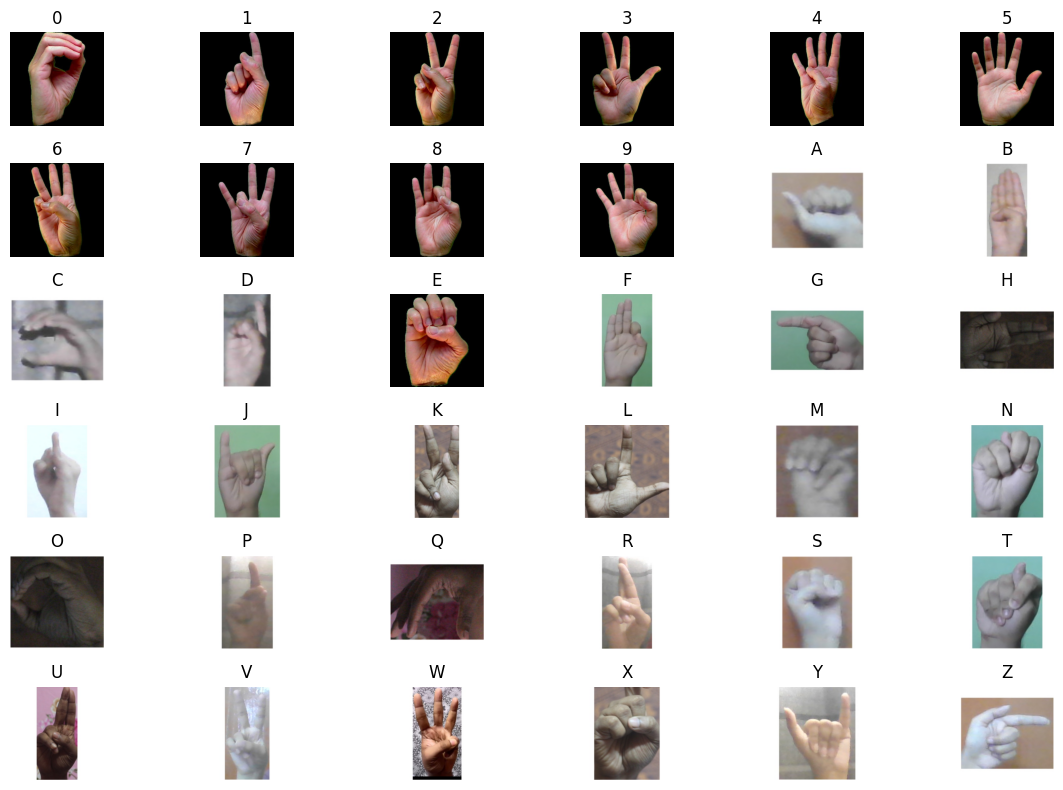

In [20]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = path+"/data"

labels = sorted(os.listdir(dataset_path))
valid_ext = (".jpg", ".jpeg", ".png")

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    # ✅ filter only image files
    images = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(valid_ext)
        and os.path.isfile(os.path.join(label_path, f))
    ]

    # skip empty folders safely
    if len(images) == 0:
        continue

    img_name = random.choice(images)
    img_path = os.path.join(label_path, img_name)

    img = Image.open(img_path)

    plt.subplot(6, 6, i + 1)
    plt.imshow(img)
    plt.title(label.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [1]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

load the base of MobileNetV2

In [2]:
BaseModel = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Find what layers we should exit from:

In [3]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_relu


The expabded relu is where we want to make the early exits, before it is projected

In [4]:
Exit1 = BaseModel.get_layer("block_3_expand_relu").output
Exit2 = BaseModel.get_layer("block_6_expand_relu").output

def ExitHead(x, NumClasses):
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  return layers.Dense(NumClasses, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, 10)
Exit2Output = ExitHead(Exit2, 10)


x = BaseModel.output
x = layers.GlobalAveragePooling2D()(x)
FinalOutput = layers.Dense(10, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])


In [5]:
NewModel.compile(
    optimizer='adam',
    loss=['categorical_crossentropy'] * 3,
    loss_weights = [0.5, 0.5, 1.0],
    metrics=['accuracy'])

In [ ]:
NewModel.fit(
    TrainData,
    validation_data = ValData,
    epochs = 10,
)